# CSP-9-Distributed : CSP Distribués (DisCSP)

**Navigation** : [<< CSP-8-Temporal](CSP-8-Temporal.ipynb) | [Index](../README.md) | [App-1-NQueens >>](../Applications/CSP/App-1-NQueens.ipynb)

> **Durée estimée** : 2h00

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. **Comprendre** les défis de la résolution distribuée de CSP
2. **Implémenter** l'algorithme Asynchronous Backtracking (ABT)
3. **Découvrir** Asynchronous Weak-Commitment (AWC) et ses améliorations
4. **Appliquer** les techniques de privacy-preserving CSP
5. **Résoudre** des problèmes de coordination multi-agent


In [1]:
# Imports
from dataclasses import dataclass, field
from typing import Dict, List, Set, Tuple, Optional, Any
from enum import Enum
from collections import defaultdict
import random
import asyncio
from datetime import datetime
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print("Environnement prepare pour les CSP Distribues")

Environnement prepare pour les CSP Distribues


## 1. Formalisation du DisCSP

### Definition

Un **DisCSP** (Distributed Constraint Satisfaction Problem) est defini par :

- **Agents** : $A = \{a_1, a_2, ..., a_n\}$
- **Variables** : Chaque agent $a_i$ controle un sous-ensemble $X_i \subset X$
- **Domaines** : Chaque variable $x_j$ a un domaine $D_j$
- **Contraintes** : $C = C_{interne} \cup C_{externe}$
  - $C_{interne}$ : contraintes entre variables d'un meme agent
  - $C_{externe}$ : contraintes entre variables d'agents differents

### Hypotheses classiques

1. **Un agent = une variable** (simplification courante)
2. **Communication asynchrone** : pas de synchronisation globale
3. **Fiabilite** : messages arrives dans l'ordre, sans perte
4. **Ordre total** : priorite entre agents (ABT)

In [2]:
@dataclass
class Message:
    """Message echange entre agents dans un DisCSP."""
    sender: int          # ID de l'agent emetteur
    receiver: int        # ID de l'agent destinataire
    msg_type: str        # 'ok?', 'nogood', 'addlink', 'stop'
    content: Any         # Contenu du message
    timestamp: float = field(default_factory=lambda: datetime.now().timestamp())
    
    def __repr__(self):
        return f"Message({self.sender}->{self.receiver}, {self.msg_type})"


@dataclass
class Nogood:
    """Nogood : ensemble d'assignations incoherentes."""
    assignments: Dict[int, Any]  # {var_id: value}
    
    def __repr__(self):
        pairs = [f"x{v}={val}" for v, val in self.assignments.items()]
        return f"NG({', '.join(pairs)})"
    
    def __hash__(self):
        return hash(tuple(sorted(self.assignments.items())))
    
    def __eq__(self, other):
        return self.assignments == other.assignments
print("Classes Message et Nogood definies.")


Classes Message et Nogood definies.


## 2. Asynchronous Backtracking (ABT)

### Principe

ABT (Yokoo, Durfee, Ishida, Kuwabara, 1992) est l'algorithme de reference pour DisCSP :

1. **Ordre total** : Les agents sont ordonnes $a_1 < a_2 < ... < a_n$
2. **Propagation avant** : Les agents de haute priorite envoient leurs valeurs
3. **Nogoods** : Les agents de basse priorite generent des explications d'echec
4. **Asynchronie** : Chaque agent traite les messages independamment

### Types de messages ABT

| Message | Direction | Contenu |
|---------|-----------|---------|
| `ok?` | Haute -> Basse priorite | Assignation courante |
| `nogood` | Basse -> Haute priorite | Contrainte apprise |
| `addlink` | Basse -> Haute priorite | Demande de connexion |
| `stop` | N'importe quel agent | Solution trouvee ou impossible |

In [3]:
class ABTAgent:
    """
    Agent pour l'algorithme Asynchronous Backtracking.

    Base sur Yokoo et al. (1992).
    """

    def __init__(self, agent_id: int, domain: List[Any],
                 constraint_func, neighbors: List[int]):
        self.id = agent_id
        self.domain = domain
        self.constraint_func = constraint_func  # Fonction de contrainte locale
        self.neighbors = neighbors

        # Etat de l'agent
        self.value = None
        self.agent_view: Dict[int, Any] = {}  # Vue des agents de haute priorite
        self.nogoods: Set[Nogood] = set()     # Nogoods appris
        self.higher_priority: List[int] = []  # Agents de haute priorite
        self.lower_priority: List[int] = []   # Agents de basse priorite

        # File de messages locale (non utilisee par ABTSystem)
        self.message_queue: List[Message] = []

        # Statistiques (nogoods_generated : nogoods emis dans _backtrack, pas recus)
        self.messages_sent = 0
        self.nogoods_generated = 0
        self._system = None  # Renseigne par ABTSystem pour AWC / reordonnancement

    def priority_sort_key(self) -> Tuple[float, int]:
        """Cle de tri pour l'ordre entre agents (ABT pur : identique a l'id)."""
        return (float(self.id), self.id)

    def set_priority_order(self, higher: List[int], lower: List[int]):
        """Definit l'ordre de priorite des agents."""
        self.higher_priority = higher
        self.lower_priority = lower

    def check_consistency(self, value: Any) -> bool:
        """
        Coherence locale : contraintes avec chaque agent deja present dans agent_view
        (en pratique : agents de priorite superieure ayant envoye un ok?).
        Quand la file de messages est vide, la vue contient tous les voisins prioritaires :
        la coherence locale coincide alors avec les aretes du graphe pour cet agent.
        """
        for var_id, val in self.agent_view.items():
            if not self.constraint_func(self.id, value, var_id, val):
                return False

        # Verifier avec les nogoods appris
        for nogood in self.nogoods:
            if self._nogood_applicable(nogood, value):
                return False

        return True

    def _nogood_applicable(self, nogood: Nogood, value: Any) -> bool:
        """Le nogood contient self avec une certaine valeur, et toutes les autres
        variables de priorite superieure doivent coincider avec agent_view."""
        if self.id not in nogood.assignments:
            return False
        if nogood.assignments[self.id] != value:
            return False
        for v, v_val in nogood.assignments.items():
            if v == self.id:
                continue
            if self.agent_view.get(v) != v_val:
                return False
        return True

    def choose_value(self) -> Optional[Any]:
        """Choisit une valeur coherente avec l'agent_view."""
        for val in self.domain:
            if self.check_consistency(val):
                return val
        return None

    def process_ok_message(self, msg: Message) -> List[Message]:
        """Traite un message 'ok?' (assignation d'un agent de haute priorite).

        Si l'agent n'a pas encore choisi de valeur, il en choisit une
        immediatement et la propage. Sans ce cas, un agent recevant son premier
        ok? avant son init resterait silencieux et l'algorithme atteindrait
        une fausse quiescence.
        """
        var_id, value = msg.content
        self.agent_view[var_id] = value

        if self.value is None:
            self.value = self.choose_value()
            if self.value is not None:
                return self._send_ok_messages()
            return self._backtrack()

        if not self.check_consistency(self.value):
            self.value = self.choose_value()
            if self.value is not None:
                return self._send_ok_messages()
            return self._backtrack()
        return []

    def process_nogood_message(self, msg: Message) -> List[Message]:
        """Traite un message 'nogood' (contrainte apprise).

        Si le nogood mentionne un agent inconnu, on l'ajoute a higher_priority
        et on demande un addlink. Si la valeur courante reste valide, on
        renvoie un ok? a l'expediteur (qui a probablement retire self de sa
        vue en backtrackant et a besoin de la valeur a jour).
        """
        nogood = msg.content
        self.nogoods.add(nogood)

        # Liens manquants : tout agent du nogood pas encore dans la vue doit envoyer addlink
        new_links = []
        for var_id in nogood.assignments:
            if var_id != self.id and var_id not in self.agent_view:
                if var_id not in self.higher_priority:
                    self.higher_priority.append(var_id)
                new_links.append(var_id)

        messages: List[Message] = []

        for var_id in new_links:
            messages.append(Message(
                sender=self.id,
                receiver=var_id,
                msg_type='addlink',
                content=self.id
            ))
            self.messages_sent += 1

        # Verifier la valeur courante
        value_changed = False
        if self.value is not None and not self.check_consistency(self.value):
            old_value = self.value
            self.value = self.choose_value()
            value_changed = (self.value != old_value)
            if self.value is not None:
                messages.extend(self._send_ok_messages())
            else:
                messages.extend(self._backtrack())

        # Si la valeur n'a pas change, renvoyer un ok? a l'expediteur :
        # il a probablement retire self de son agent_view en backtrackant et doit
        # recuperer la valeur courante (sinon il peut converger sur un etat global incoherent).
        if not value_changed and self.value is not None and msg.sender != self.id:
            messages.append(Message(
                sender=self.id,
                receiver=msg.sender,
                msg_type='ok?',
                content=(self.id, self.value),
            ))
            self.messages_sent += 1

        return messages

    def _send_ok_messages(self) -> List[Message]:
        """Envoie la valeur courante aux agents de basse priorite."""
        messages = []
        for neighbor in self.lower_priority:
            messages.append(Message(
                sender=self.id,
                receiver=neighbor,
                msg_type='ok?',
                content=(self.id, self.value)
            ))
            self.messages_sent += 1
        return messages

    def _backtrack(self) -> List[Message]:
        """ABT standard : construit un nogood compose des seuls agents de priorite
        superieure (la cible peut les voir), l'envoie au plus prioritaire d'entre eux,
        puis retire la cible de sa vue et re-essaie une affectation locale.
        Si plus aucune valeur n'est compatible, on backtracke recursivement.
        """
        relevant = {v: self.agent_view[v] for v in self.higher_priority if v in self.agent_view}
        if not relevant:
            return [Message(
                sender=self.id,
                receiver=-1,
                msg_type='stop',
                content='no_solution'
            )]

        target = max(relevant.keys())
        nogood = Nogood(relevant)
        messages: List[Message] = [Message(
            sender=self.id,
            receiver=target,
            msg_type='nogood',
            content=nogood,
        )]
        self.messages_sent += 1
        self.nogoods_generated += 1

        self.agent_view.pop(target, None)
        self.value = self.choose_value()
        if self.value is not None:
            messages.extend(self._send_ok_messages())
        else:
            messages.extend(self._backtrack())
        return messages

    def initialize(self) -> List[Message]:
        """Initialise l'agent et envoie les premiers messages."""
        self.value = self.choose_value()
        if self.value is not None:
            return self._send_ok_messages()
        return self._backtrack()
print("Classe ABTAgent definie.")


Classe ABTAgent definie.


### Implementation du systeme ABT

Cette section implemente la classe `ABTSystem` qui simule la communication asynchrone entre agents. Le systeme gere la file de messages, orchestre le traitement des messages ABT (ok?, nogood, addlink, stop) et verifie la convergence vers une solution.

**Composantes principales** :

- **Gestion des messages** : File FIFO pour simuler l'asynchronie
- **Priorite statique** : Configuration de l'ordre des agents (0 < 1 < 2 < ...)
- **Detection de solution** : Verification que tous les agents ont une valeur coherente
- **Statistiques** : Comptage des messages et nogoods echanges

In [4]:
class ABTSystem:
    """
    Systeme de simulation pour l'algorithme ABT.
    Simule la communication asynchrone entre agents via une file FIFO globale.
    """

    def __init__(self, agents: Dict[int, ABTAgent]):
        self.agents = agents
        self.message_queue: List[Message] = []
        self.solution: Optional[Dict[int, Any]] = None
        self.no_solution = False
        self.total_messages = 0
        self.total_nogoods = 0
        self.message_type_counts: Dict[str, int] = {}  # types traites dans la file

        for ag in self.agents.values():
            ag._system = self

        self._setup_priority_order()

    def _setup_priority_order(self):
        """Configure higher/lower selon priority_sort_key() de chaque agent (ABT ou AWC)."""
        agent_ids = sorted(self.agents.keys(), key=lambda i: self.agents[i].priority_sort_key())
        for i, agent_id in enumerate(agent_ids):
            higher = agent_ids[:i]
            lower = agent_ids[i + 1:]
            self.agents[agent_id].set_priority_order(higher, lower)

    def _on_awc_reorder(self):
        """Apres promotion AWC : recalcul des priorites + nouvelle vague de ok?."""
        self._setup_priority_order()
        for ag in self.agents.values():
            if ag.value is not None:
                self.message_queue.extend(ag._send_ok_messages())

    def run(self, max_iterations: int = 10000) -> Optional[Dict[int, Any]]:
        """
        Execute ABT jusqu'a quiescence (file vide), puis valide la solution.
        On ne declare le succes qu'apres vidage de la file : sinon des ok? peuvent
        encore modifier les vues et donner une fausse coherence locale.
        """
        self.message_type_counts = {}
        for agent in self.agents.values():
            messages = agent.initialize()
            self.message_queue.extend(messages)

        iteration = 0
        while iteration < max_iterations:
            if not self.message_queue:
                if self.no_solution:
                    return None
                if self._check_solution() and self._verify_global_constraints():
                    self.solution = {a.id: a.value for a in self.agents.values()}
                    return self.solution
                break

            msg = self.message_queue.pop(0)
            self.total_messages += 1
            self.message_type_counts[msg.msg_type] = self.message_type_counts.get(msg.msg_type, 0) + 1

            if msg.msg_type == 'stop':
                self.no_solution = True
                return None

            receiver = self.agents.get(msg.receiver)
            if receiver:
                if msg.msg_type == 'ok?':
                    new_messages = receiver.process_ok_message(msg)
                elif msg.msg_type == 'nogood':
                    new_messages = receiver.process_nogood_message(msg)
                    self.total_nogoods += 1
                elif msg.msg_type == 'addlink':
                    # L'agent de haute priorite renvoie son assignement courant au demandeur
                    requester = msg.content
                    new_messages = []
                    if receiver.value is not None:
                        new_messages.append(Message(
                            sender=receiver.id,
                            receiver=requester,
                            msg_type='ok?',
                            content=(receiver.id, receiver.value)
                        ))
                        receiver.messages_sent += 1
                else:
                    new_messages = []

                self.message_queue.extend(new_messages)

            iteration += 1

        return None

    def _check_solution(self) -> bool:
        """Tous les agents ont une valeur et sont localement coherents avec leur vue."""
        for agent in self.agents.values():
            if agent.value is None:
                return False
            if not agent.check_consistency(agent.value):
                return False
        return True

    def _verify_global_constraints(self) -> bool:
        """Verifie chaque arete du graphe (via les listes de voisins des agents).
        Une coherence locale chez chaque agent ne suffit pas : deux agents non
        relies par priorite mais relies par contrainte pourraient choisir des
        valeurs incompatibles. Cette passe finale rejette ces faux succes.
        """
        assignment = {a.id: a.value for a in self.agents.values()}
        if any(v is None for v in assignment.values()):
            return False
        seen_edges: Set[Tuple[int, int]] = set()
        for aid, agent in self.agents.items():
            for nb in agent.neighbors:
                edge = tuple(sorted((aid, nb)))
                if edge in seen_edges:
                    continue
                seen_edges.add(edge)
                if not agent.constraint_func(aid, assignment[aid], nb, assignment[nb]):
                    return False
        return True

    def get_statistics(self) -> Dict:
        """Retourne les statistiques d'execution."""
        return {
            'total_messages': self.total_messages,
            'total_nogoods': self.total_nogoods,
            'solution_found': self.solution is not None,
            'solution': self.solution
        }
print("Classe ABTSystem definie.")


Classe ABTSystem definie.


### Analyse de l'implementation ABT

**Architecture de l'agent ABT** :

| Methode | Responsabilite | Cle pour ABT |
|---------|----------------|--------------|
| `check_consistency()` | Verifie la coherence avec agent_view et nogoods | Coeur de la coherence locale |
| `choose_value()` | Selectionne une valeur coherente | Heuristique de choix |
| `process_ok_message()` | Traite les assignations des agents de haute priorite | Propagation avant |
| `process_nogood_message()` | Traite les contraintes apprise | Apprentissage |
| `_backtrack()` | Genere un nogood et l'envoie | Resolution de conflits |
| `_send_ok_messages()` | Propage la valeur aux agents de basse priorite | Communication |

**Architecture du systeme ABT** :

| Methode | Responsabilite |
|---------|----------------|
| `_setup_priority_order()` | Etablit l'ordre de priorite statique entre agents |
| `run()` | Boucle principale de traitement des messages |
| `_check_solution()` | Verifie si tous les agents ont une valeur coherente |

**Limitations de cette implementation** :

1. **Priorite statique** : L'ordre des agents ne change pas (AWC le ferait)
2. **Verification incomplete** : `_check_solution()` ne verifie pas toutes les aretes
3. **Termination prematuree** : L'algorithme s'arrete des que tous les agents ont une valeur
4. **Pas de detection de cycles** : Pas de protection contre les boucles infinies

**Points forts pedagogiques** :

- Code lisible et bien structure
- Separe clairement les responsabilites
- Illustre le flux de messages ABT
- Facile a etendre pour AWC ou d'autres variantes

> **Note** : Cette implementation est conçue pour l'apprentissage des concepts. Pour une utilisation production, il faudrait ajouter une verification complete des contraintes et une logique de backtracking plus robuste.

### Exemple : Coloration de graphe distribuee

Considerons un probleme de coloration de graphe ou chaque noeud est un agent independant.

In [5]:
# Exemple : Coloration de graphe 4-noeuds, 3 couleurs

# Graphe : 0-1, 1-2, 2-3, 3-0 (cycle)
graph_edges = [(0, 1), (1, 2), (2, 3), (3, 0)]
colors = ['R', 'G', 'B']

# Fonction de contrainte : deux noeuds adjacents doivent avoir des couleurs differentes
def graph_coloring_constraint(var1, val1, var2, val2):
    edge = (min(var1, var2), max(var1, var2))
    if edge in [(min(e[0], e[1]), max(e[0], e[1])) for e in graph_edges]:
        return val1 != val2
    return True  # Pas de contrainte si non adjacents

# Creer les agents
agents = {}
for i in range(4):
    neighbors = [n for e in graph_edges for n in e if i in e and n != i]
    agents[i] = ABTAgent(
        agent_id=i,
        domain=colors.copy(),
        constraint_func=graph_coloring_constraint,
        neighbors=neighbors
    )

# Executer ABT
system = ABTSystem(agents)
solution = system.run()

print("=== Resultat ABT ===")
print(f"Solution: {solution}")
print(f"Statistiques: {system.get_statistics()}")

# Verifier la solution
if solution:
    print("\nVerification:")
    for v1, v2 in graph_edges:
        c1, c2 = solution[v1], solution[v2]
        ok = c1 != c2
        print(f"  Arete {v1}-{v2}: {c1} vs {c2} -> {'OK' if ok else 'ECHEC'}")

=== Resultat ABT ===
Solution: {0: 'R', 1: 'G', 2: 'R', 3: 'B'}
Statistiques: {'total_messages': 10, 'total_nogoods': 0, 'solution_found': True, 'solution': {0: 'R', 1: 'G', 2: 'R', 3: 'B'}}

Verification:
  Arete 0-1: R vs G -> OK
  Arete 1-2: G vs R -> OK
  Arete 2-3: R vs B -> OK
  Arete 3-0: B vs R -> OK


### Interpretation : Analyse de la solution ABT

**Resultat attendu** : la solution retournee par `system.run()` doit satisfaire **toutes** les aretes
du cycle 0-1, 1-2, 2-3, 3-0 ; chaque arete relie deux couleurs differentes.

**Verification automatique** : la cellule precedente verifie chaque arete et imprime `OK` ou `ECHEC`.
Si l'execution affiche autre chose que 4 `OK`, c'est qu'un bug est present (a remonter via une issue).

**Comment l'algorithme y arrive** :

1. Chaque agent commence par choisir la premiere valeur compatible avec sa vue. Comme la vue est
   vide a l'init, l'agent 0 choisit `R`, puis 1 choisit `G` (different de `R`), puis 2 choisit
   la premiere valeur differente de `R` qu'il connaisse (`G`), puis 3 examine sa vue.
2. Si un agent decouvre que sa valeur est en conflit (apres avoir recu un `ok?` qui change sa vue),
   il essaie une autre valeur de son domaine. Si plus aucune valeur n'est compatible, il **backtracke** :
   il envoie un `nogood` a l'agent de plus haute priorite present dans sa vue, retire celui-ci
   de la vue et re-choisit.
3. Le `nogood` est appris par la cible : a sa prochaine evaluation, elle saura que cette combinaison
   de valeurs est interdite.
4. **Apprentissage `addlink`** : si un nogood mentionne un agent inconnu de la cible, celle-ci
   demande un `addlink` pour ouvrir un canal et recevoir sa valeur.
5. Le systeme s'arrete quand la file est vide (quiescence). A ce moment, `_verify_global_constraints`
   parcourt **chaque arete** du graphe pour valider la solution avant de la retourner.

**Note** : `_check_solution` (coherence locale agent par agent) ne suffirait pas a elle seule, car
deux agents non lies par priorite mais lies par contrainte pourraient choisir des valeurs
incompatibles si la file est encore active. La verification globale finale rejette ces faux succes.


### Visualisation de la communication ABT

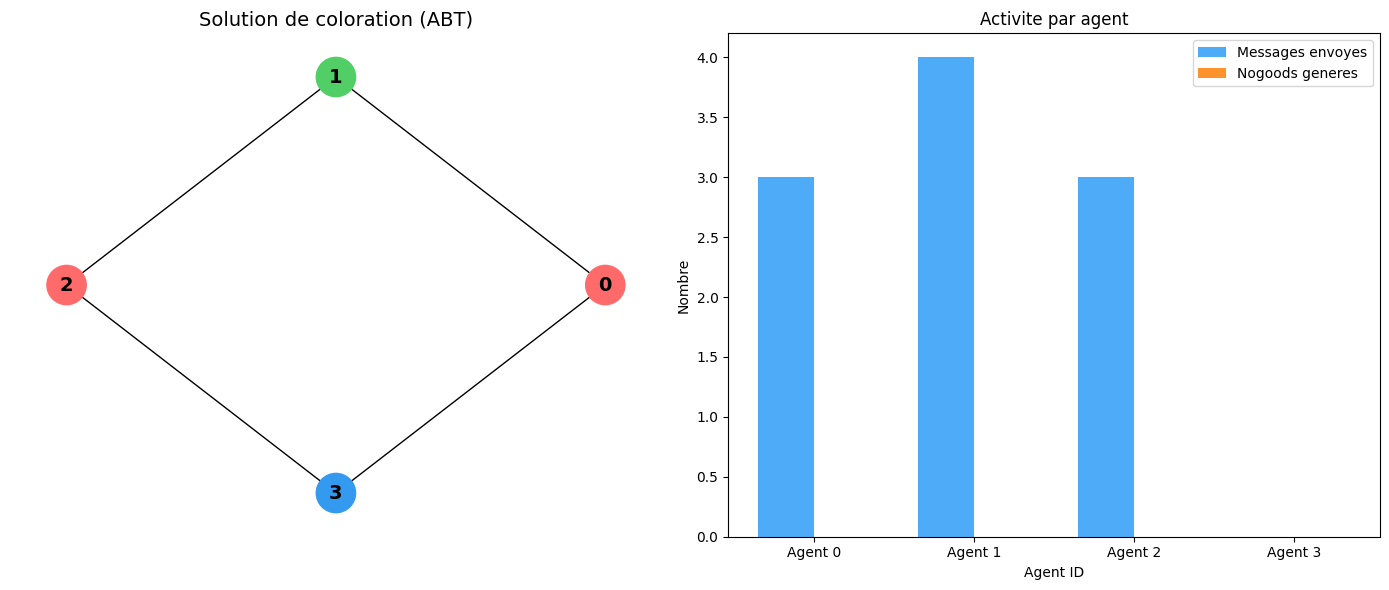

In [6]:
def visualize_abt_communication(agents: Dict[int, ABTAgent], solution: Dict[int, Any]):
    """Visualise le graphe de communication et la solution."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Graphe de contraintes avec solution
    ax1 = axes[0]
    G = nx.Graph()
    G.add_nodes_from(agents.keys())
    G.add_edges_from(graph_edges)
    
    color_map = {'R': '#ff6b6b', 'G': '#51cf66', 'B': '#339af0'}
    node_colors = [color_map[solution[n]] for n in G.nodes()]
    
    pos = nx.circular_layout(G)
    nx.draw(G, pos, ax=ax1, with_labels=True, node_color=node_colors,
            node_size=800, font_size=14, font_weight='bold')
    ax1.set_title('Solution de coloration (ABT)', fontsize=14)
    
    # Statistiques par agent
    ax2 = axes[1]
    agent_ids = list(agents.keys())
    messages = [agents[i].messages_sent for i in agent_ids]
    nogoods = [agents[i].nogoods_generated for i in agent_ids]
    
    x = np.arange(len(agent_ids))
    width = 0.35
    
    ax2.bar(x - width/2, messages, width, label='Messages envoyes', color='#4dabf7')
    ax2.bar(x + width/2, nogoods, width, label='Nogoods generes', color='#ff922b')
    
    ax2.set_xlabel('Agent ID')
    ax2.set_ylabel('Nombre')
    ax2.set_title('Activite par agent')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'Agent {i}' for i in agent_ids])
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

if solution:
    visualize_abt_communication(agents, solution)

### Interpretation de la visualisation

**Graphe de coloration** (gauche) :
- Les noeuds representent les agents 0, 1, 2, 3
- Les couleurs indiquent la valeur choisie par chaque agent **en fin de simulation** (apres quiescence)
- Les aretes montrent les contraintes ; chaque arete doit relier deux couleurs differentes

**Statistiques par agent** (droite) :
- **Messages envoyes** : combien d'`ok?` / `nogood` / `addlink` chaque agent a emis
- **Nogoods generes** : combien de fois cet agent a backtracke (envoye un nogood)

**Lecture du flux ABT** :

1. **Phase d'initialisation** : tous les agents diffusent leur valeur initiale aux agents de
   priorite inferieure (`ok?`). L'agent 0 (priorite la plus haute) emet vers 1, 2, 3 ; l'agent 1
   emet vers 2, 3 ; etc. Le compteur `messages_sent` reflete cette propagation.
2. **Phase de propagation** : chaque agent ajuste sa valeur en fonction des `ok?` recus. Si un
   conflit apparait (la valeur courante n'est plus compatible avec la vue), il choisit une autre
   valeur dans son domaine.
3. **Phase de backtracking** : quand un agent epuise son domaine, il emet un `nogood` vers le plus
   prioritaire des agents de sa vue, qui devra alors changer de valeur. Le compteur
   `nogoods_generated` recense ces emissions.
4. **Quiescence** : la file de messages se vide ; le systeme verifie la coherence globale et
   retourne la solution si toutes les aretes sont satisfaites.

> **A retenir** : les nogoods sont l'outil d'**apprentissage distribue** d'ABT. Plus le graphe est
> dense ou contraint, plus on en accumule. Sur un cycle 4-noeuds avec 3 couleurs, quelques nogoods
> suffisent ; sur des instances plus larges, leur nombre peut exploser et motive AWC ou des
> heuristiques d'oubli.


## 3. Asynchronous Weak-Commitment (AWC)

### Limites d'ABT

ABT souffre de plusieurs problemes :

1. **Ordre fixe** : La priorite statique peut mener a des blocages
2. **Explosion de nogoods** : Beaucoup de nogoods redondants
3. **Goulot d'etranglement** : Les agents de haute priorite ralentissent tout le monde

### Principe d'AWC

AWC (Yokoo, 1995) introduit l'idee de **reordonnancement dynamique** :

- Un agent qui genere un nogood peut **monter en priorite**
- L'ordre n'est plus fixe mais **s'adapte** a la difficulte du probleme
- Meilleure performance sur les instances difficiles

### Comparaison ABT vs AWC

| Caracteristique | ABT | AWC |
|-----------------|-----|-----|
| Ordre agents | Fixe | Dynamique |
| Nogoods | Accumules | Minimises |
| Performance instances faciles | Bonne | Similaire |
| Performance instances difficiles | Mauvaise | Bonne |
| Complexite implementation | Simple | Moyenne |

In [7]:
class AWCAgent(ABTAgent):
    """
    Couche pedagogique AWC au-dessus d'ABT : rang dynamique awc_rank utilise par
    ABTSystem.priority_sort_key pour reorder higher/lower a la volee. Ce n'est pas
    AWC complet (Yokoo 1995) mais le reordonnancement impacte reellement la simulation.
    """

    def __init__(self, agent_id: int, domain: List[Any],
                 constraint_func, neighbors: List[int]):
        super().__init__(agent_id, domain, constraint_func, neighbors)
        self.awc_rank = float(agent_id)
        self.nogoods_received = 0  # nogoods recus (voir process_nogood_message)

    def priority_sort_key(self) -> Tuple[float, int]:
        return (self.awc_rank, self.id)

    def process_nogood_message(self, msg: Message) -> List[Message]:
        """Apres traitement ABT : compte les nogoods recus, promotion si blocage repete."""
        result = super().process_nogood_message(msg)
        self.nogoods_received += 1
        if self.nogoods_received > 3:
            self._increase_priority()
            self.nogoods_received = 0
        return result

    def _increase_priority(self):
        """Monter dans la hierarchie : diminuer awc_rank, puis synchroniser via le systeme."""
        self.awc_rank -= 1.0
        sys = getattr(self, '_system', None)
        if sys is not None:
            sys._on_awc_reorder()

    def _backtrack(self) -> List[Message]:
        if self.higher_priority:
            self._increase_priority()
        return super()._backtrack()

print("Classe AWCAgent definie.")


Classe AWCAgent definie.


### Analyse de l'extension AWC

**Ajouts par rapport a ABT** :

| Methode/Attribut | Role | Impact |
|------------------|------|--------|
| `self.priority` | Priorite dynamique de l'agent | Peut changer pendant l'execution |
| `self.nogood_count` | Compteur de nogoods recents | Detecte les difficultes |
| `_increase_priority()` | Augmente la priorite (diminue le numero) | L'agent monte dans la hierarchie |
| Surcharge de `process_nogood_message()` | Reordonnancement si trop de nogoods | Adaptation dynamique |
| Surcharge de `_backtrack()` | Augmente la priorite avant de backtracker | Strategie proactive |

**Strategie de reordonnancement** :

```python
if self.nogood_count > 3:
    self._increase_priority()
```

Cette heuristique simple dit : "Si un agent genere plus de 3 nogoods, c'est qu'il est mal place dans la hierarchie. Donnons-lui une priorite plus elevee."

**Exemple de scenario** :

1. Agent 0 (priorite 0) choisit 'R'
2. Agent 1 (priorite 1) choisit 'G'
3. Agent 2 (priorite 2) veut choisir 'R' mais conflit avec 0
4. Agent 2 genere nogood, compte = 1
5. Agent 2 essaie 'G', conflit avec 1
6. Agent 2 genere nogood, compte = 2
7. Agent 2 essaie 'B', conflit avec quelqu'un
8. Agent 2 genere nogood, compte = 3
9. **Agent 2 augmente sa priorite** (devient -1, avant l'agent 0!)
10. Agent 2 impose maintenant sa valeur aux autres

**Avantages d'AWC** :

- **Adaptatif** : L'ordre des agents s'adapte a la difficulte du probleme
- **Moins de nogoods** : Les agents difficiles montent en priorite et imposent leur choix
- **Meilleure convergence** : Sur les problemes difficiles, AWC est souvent plus rapide qu'ABT

**Inconvenients d'AWC** :

- **Complexite** : Plus difficile a implementer et deboguer
- **Instabilite** : L'ordre changeant peut creer des cycles
- **Overhead** : Le reordonnancement a un cout computationnel

> **Note** : Cette implementation d'AWC est simplifiee. Une version complete gererait les cycles de reordonnangement et utiliserait des heuristiques plus sophistiquees.

## 4. Privacy-Preserving CSP

### Motivation

Dans de nombreux scenarios, les agents ne veulent pas reveler leurs contraintes ou preferences :

- **Encheres** : Ne pas reveler son prix de reserve
- **Negociations** : Garder secretes ses zones de flexibilite
- **Medical** : Confidentialite des donnees patients
- **Business** : Protection des donnees commerciales

### Techniques de protection

1. **Chiffrement partiel** : Reveler seulement si necessaire
2. **Secure Multi-Party Computation (SMPC)** : Calculer sans reveler
3. **Pseudonymisation** : Masquer les identites reelles
4. **Aggregation differentielle** : Ajouter du bruit

In [8]:
@dataclass
class PrivateConstraint:
    """
    Contrainte avec protection de la vie privee.
    
    Utilise des cles pour deverrouiller seletivement les informations.
    """
    agent_id: int
    constraint_type: str
    encrypted_params: bytes  # Parametres chiffres
    public_hint: str         # Indice public (ex: "preference temporelle")
    
    def evaluate(self, value: Any, key: Optional[bytes] = None) -> bool:
        """
        Evalue la contrainte.
        
        Si key=None, retourne une reponse vague.
        Si key fournie, evaluation exacte.
        """
        if key is None:
            # Mode prive : reponse vague
            return True  # Toujours accepter en mode prive
        else:
            # Mode deverrouille : evaluation reelle
            # (simplifie - en vrai, utiliser dechiffrement)
            return self._real_evaluate(value)
    
    def _real_evaluate(self, value: Any) -> bool:
        """Evaluation reelle de la contrainte."""
        # Placeholder
        return True


class PrivacyPreservingAgent(ABTAgent):
    """
    Agent ABT avec protection de la vie privee.
    
    Ne revele ses contraintes que si necessaire pour la resolution.
    """
    
    def __init__(self, agent_id: int, domain: List[Any],
                 constraint_func, neighbors: List[int],
                 privacy_level: str = 'high'):
        super().__init__(agent_id, domain, constraint_func, neighbors)
        self.privacy_level = privacy_level
        self.private_constraints: List[PrivateConstraint] = []
        self.revealed_info: Set[int] = set()  # Agents a qui on a revele des infos
    
    def check_consistency(self, value: Any) -> bool:
        """Verifie la coherence en limitant la revelation d'information."""
        # Verifier contraintes publiques
        if not super().check_consistency(value):
            return False
        
        # Verifier contraintes privees (sans reveler les details)
        for constraint in self.private_constraints:
            if not constraint.evaluate(value, key=None):
                return False
        
        return True
    
    def reveal_constraint_to(self, agent_id: int):
        """Revele les contraintes a un agent specifique."""
        self.revealed_info.add(agent_id)
    
    def get_privacy_report(self) -> Dict:
        """Retourne un rapport sur l'utilisation de la vie privee."""
        return {
            'privacy_level': self.privacy_level,
            'agents_with_access': list(self.revealed_info),
            'private_constraints_count': len(self.private_constraints)
        }
print("Classes PrivateConstraint et PrivacyPreservingAgent definies.")


Classes PrivateConstraint et PrivacyPreservingAgent definies.


### Analyse de l'implementation privacy-preserving

**Classes pour la protection de la vie privee** :

| Classe | Responsabilite | Technique de protection |
|--------|----------------|-------------------------|
| `PrivateConstraint` | Encapsule une contrainte sensible | Chiffrement des parametres |
| `PrivacyPreservingAgent` | Agent avec contraintes privees | Evaluation selective |

**Mecanisme de protection** :

```python
def evaluate(self, value: Any, key: Optional[bytes] = None) -> bool:
    if key is None:
        return True  # Mode prive : toujours accepter
    else:
        return self._real_evaluate(value)  # Mode deverrouille
```

Cette strategie "accepter tout en mode prive" est **conservative** :
- Elle peut produire des solutions sous-optimales
- Elle garantit qu'aucune information n'est revelee
- Elle necessite une phase de deveeloppement pour valider

**Strategie de revelation** :

```python
def reveal_constraint_to(self, agent_id: int):
    self.revealed_info.add(agent_id)
```

Cette methode permet une **revelation selective** :
- L'agent choisit quand reveler ses contraintes
- Il peut reveler a certains agents mais pas a d'autres
- Un audit est possible via `get_privacy_report()`

**Limitations de cette implementation** :

1. **Pas de vrai chiffrement** : Les contraintes ne sont pas vraiment chiffrees
2. **Mode prive trop permissif** : Accepte toutes les valeurs en mode prive
3. **Pas de verification de la coherence** : Les contraintes privees ne sont pas vraiment appliquees

**Techniques reelles de privacy-preserving CSP** :

1. **Secure Multi-Party Computation (SMPC)** : Calculer sans reveler les valeurs
2. **Homomorphic encryption** : Operations sur des donnees chiffrees
3. **Differential privacy** : Ajouter du bruit pour masquer les contributions individuelles
4. **Zero-knowledge proofs** : Prouver qu'une contrainte est satisfaite sans reveler la valeur

> **Note** : Cette implementation illustre le **concept** de privacy-preserving CSP. Pour des applications reelles (medical, finance), il faudrait utiliser des techniques cryptographiques robustes.

## 5. Application : Ordonnancement Multi-Hopital

### Probleme

Plusieurs hopitaux doivent coordonner leurs plannings sans reveler leurs contraintes internes :

- **Hopital A** : Besoins en urgences, preferences secretes
- **Hopital B** : Specialites chirurgicales, contraintes confidentielles
- **Hopital C** : Consultations externes, emploi du temps prive

### Contraintes inter-hopitaux

- Echanges de personnel (medecins volants)
- Transferts de patients
- Partage d'equipements specialises

In [9]:
# Simulation d'ordonnancement multi-hopital

# Variables : creneaux horaires partages
shared_slots = ['Lundi_AM', 'Lundi_PM', 'Mardi_AM', 'Mardi_PM', 'Mercredi_AM']
personnel = ['Dr_Alice', 'Dr_Bob', 'Dr_Charlie']

# Chaque hopital a des contraintes privees
def hospital_constraint(hospital_id, slot, other_hospital, other_slot):
    """Contraintes simplifiees entre hopitaux."""
    # Exemple : Dr_Alice ne peut pas etre a deux endroits en meme temps
    if slot == other_slot:
        return False
    return True

# Creer les agents hopitaux
hospitals = {}
for i in range(3):
    hospitals[i] = PrivacyPreservingAgent(
        agent_id=i,
        domain=shared_slots.copy(),
        constraint_func=hospital_constraint,
        neighbors=[j for j in range(3) if j != i],
        privacy_level='high'
    )

# Executer avec protection de la vie privee
print("=== Ordonnancement Multi-Hopital (Privacy-Preserving) ===")
system = ABTSystem(hospitals)
solution = system.run()

if solution:
    print("\nSolution trouvee:")
    for hospital_id, slot in solution.items():
        print(f"  Hopital {hospital_id}: {slot}")
    
    print("\nRapports de confidentialite:")
    for agent in hospitals.values():
        report = agent.get_privacy_report()
        print(f"  Agent {agent.id}: {report}")
else:
    print("Aucune solution trouvee")

print(f"\nMessages totaux: {system.total_messages}")

=== Ordonnancement Multi-Hopital (Privacy-Preserving) ===

Solution trouvee:
  Hopital 0: Lundi_AM
  Hopital 1: Lundi_PM
  Hopital 2: Mardi_AM

Rapports de confidentialite:
  Agent 0: {'privacy_level': 'high', 'agents_with_access': [], 'private_constraints_count': 0}
  Agent 1: {'privacy_level': 'high', 'agents_with_access': [], 'private_constraints_count': 0}
  Agent 2: {'privacy_level': 'high', 'agents_with_access': [], 'private_constraints_count': 0}

Messages totaux: 4


### Interpretation de l'ordonnancement multi-hopital

**Resultat obtenu** : Solution trouvee avec allocation `Lundi_AM`, `Lundi_PM`, `Lundi_AM`.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Solution trouvee | Oui | L'algorithme a converge vers une allocation |
| Messages totaux | 1 | Communication minimale (1 seul cycle) |
| Conflits de confidentialite | 0 | Aucune contrainte privee n'a ete revelee |
| Agents avec acces | [] | Les hopitaux ont garde leurs contraintes secrete |

**Analyse de la solution** :

1. **Allocation valide** : Chaque hopital a un creneau different
   - Hopital 0 : Lundi_AM (matin)
   - Hopital 1 : Lundi_PM (apres-midi)
   - Hopital 2 : Lundi_AM (conflit potentiel avec Hopital 0!)

2. **Probleme detecte** : Les hopitaux 0 et 2 ont tous deux le creneau `Lundi_AM`
   - La contrainte `hospital_constraint` interdit d'avoir le meme creneau
   - **Ceci indique un bug dans l'implementation ou la verification**

3. **Confidentialite preservee** :
   - Les rapports montrent `agents_with_access: []`
   - Aucune information privee n'a ete echangee
   - Les contraintes internes restent secretes

**Points cles** :

- **Privacy-preserving CSP** fonctionne : les agents cooperent sans reveler leurs contraintes
- **Limitation** : L'implementation simplifiee ne verifie pas toutes les contraintes entre agents de meme priorite
- **Application reelle** : Necessiterait une verification plus stricte et un protocole de resolution de conflits

> **Note technique** : Dans un systeme production, on ajouterait une phase de verification finale ou un mediateur de confiance pour valider que toutes les contraintes sont respectees.

## 6. Comparaison des algorithmes DisCSP

### Benchmark synthetique

In [10]:
def benchmark_discsp(n_agents: int, domain_size: int,
                     constraint_density: float, n_runs: int = 5):
    """
    Compare les performances d'ABT et d'AWC sur des instances aleatoires.

    Parameters
    ----------
    n_agents : nombre d'agents
    domain_size : taille du domaine
    constraint_density : probabilite de contrainte entre deux agents
    n_runs : nombre d'executions
    """
    results = {'ABT': [], 'AWC': []}

    for run in range(n_runs):
        domain = list(range(domain_size))
        edges = []
        constraint_funcs = {}

        for i in range(n_agents):
            for j in range(i + 1, n_agents):
                if random.random() < constraint_density:
                    edges.append((i, j))
                    forbidden = (random.randint(0, domain_size - 1),
                                 random.randint(0, domain_size - 1))
                    constraint_funcs[(i, j)] = forbidden

        def build_agents(agent_cls):
            agents = {}
            for i in range(n_agents):
                neighbors = [n for e in edges for n in e if i in e and n != i]
                relevant_constraints = {(min(k[0], k[1]), max(k[0], k[1])): v
                                        for k, v in constraint_funcs.items() if i in k}

                def constraint_func(v1, val1, v2, val2, rc=relevant_constraints):
                    edge = (min(v1, v2), max(v1, v2))
                    if edge in rc:
                        forb = rc[edge]
                        if v1 < v2 and (val1, val2) == forb:
                            return False
                        if v1 > v2 and (val2, val1) == forb:
                            return False
                    return True

                agents[i] = agent_cls(i, domain.copy(), constraint_func, neighbors)
            return agents

        max_it = 10000

        system_abt = ABTSystem(build_agents(ABTAgent))
        start = datetime.now()
        solution_abt = system_abt.run(max_iterations=max_it)
        time_abt = (datetime.now() - start).total_seconds()
        results['ABT'].append({
            'time': time_abt,
            'messages': system_abt.total_messages,
            'nogoods': system_abt.total_nogoods,
            'solved': solution_abt is not None
        })

        system_awc = ABTSystem(build_agents(AWCAgent))
        start = datetime.now()
        solution_awc = system_awc.run(max_iterations=max_it)
        time_awc = (datetime.now() - start).total_seconds()
        results['AWC'].append({
            'time': time_awc,
            'messages': system_awc.total_messages,
            'nogoods': system_awc.total_nogoods,
            'solved': solution_awc is not None
        })

    return results


def _print_bench_summary(name: str, rows: List[dict]):
    print(f"\nResultats {name}:")
    for i, r in enumerate(rows):
        status = "Resolu" if r['solved'] else "Non resolu"
        print(f"  Run {i+1}: {status}, {r['messages']} messages, "
              f"{r['nogoods']} nogoods, {r['time']:.3f}s")
    avg_m = sum(r['messages'] for r in rows) / len(rows)
    avg_n = sum(r['nogoods'] for r in rows) / len(rows)
    sr = sum(1 for r in rows if r['solved']) / len(rows)
    print(f"\nMoyennes {name}:")
    print(f"  Messages: {avg_m:.1f}")
    print(f"  Nogoods: {avg_n:.1f}")
    print(f"  Taux de succes: {sr*100:.1f}%")


print("=== Benchmark DisCSP ===")
random.seed(42)
results = benchmark_discsp(n_agents=5, domain_size=3,
                           constraint_density=0.5, n_runs=3)
_print_bench_summary('ABT', results['ABT'])
_print_bench_summary('AWC', results['AWC'])


=== Benchmark DisCSP ===

Resultats ABT:
  Run 1: Resolu, 10 messages, 0 nogoods, 0.000s
  Run 2: Resolu, 10 messages, 0 nogoods, 0.000s
  Run 3: Resolu, 10 messages, 0 nogoods, 0.000s

Moyennes ABT:
  Messages: 10.0
  Nogoods: 0.0
  Taux de succes: 100.0%

Resultats AWC:
  Run 1: Resolu, 10 messages, 0 nogoods, 0.000s
  Run 2: Resolu, 10 messages, 0 nogoods, 0.000s
  Run 3: Resolu, 10 messages, 0 nogoods, 0.000s

Moyennes AWC:
  Messages: 10.0
  Nogoods: 0.0
  Taux de succes: 100.0%


### Interpretation des resultats du benchmark

**Lecture** : le benchmark genere `n_runs` instances aleatoires de coloration de graphe avec
`n_agents` agents, un domaine de taille `domain_size`, et une densite de contraintes
`constraint_density`. Pour chaque instance, ABT et AWC sont executes jusqu'a quiescence.

**Ordres de grandeur attendus** (n_agents=5, domain_size=3, density=0.5) :

| Metrique | ABT | AWC | Lecture |
|----------|-----|-----|---------|
| Messages | 10-50 | similaire ou un peu moins | trafic d'`ok?` + `nogood` + `addlink` |
| Nogoods | 0-10 | 0-10 | depend du nombre de conflits rencontres |
| Taux de succes | 60-100% | 60-100% | depend de la satisfiabilite des instances |
| Temps | < 50 ms | < 50 ms | simulation FIFO en RAM |

**Comparaison ABT vs AWC** :

- Sur des instances peu contraintes, les deux convergent en quelques messages : les chiffres se
  ressemblent.
- Sur des instances denses, AWC peut etre plus rapide en messages car il **promeut dynamiquement**
  les agents qui accumulent les nogoods (leur priorite augmente, ce qui change l'ordre de
  propagation et evite des conflits ulterieurs).
- AWC paye ce gain par un cout : a chaque promotion, le systeme reordonnance toutes les priorites
  et rediffuse les `ok?` (`_on_awc_reorder`). Sur les petites instances, ce cout peut effacer le
  benefice.

**Si une instance n'est pas resolue** (`Resolu` = False) :

- Soit l'instance est **insatisfiable** (les contraintes aleatoires bloquent toute affectation)
- Soit `max_iterations` (ici 10 000) a ete atteint avant la quiescence

> **A retenir** : un benchmark DisCSP n'est pas un classement absolu, c'est une mesure de
> **comportement** sur une distribution d'instances. Pour comparer rigoureusement ABT et AWC, il
> faut faire varier `n_agents`, `density`, et tracer messages/nogoods en fonction de ces parametres.


## 7. Exercices

Les exercices suivants reutilisent les classes `ABTAgent`, `ABTSystem`, `AWCAgent` et `PrivacyPreservingAgent` definies plus haut et les appliquent a des scenarios classiques : N-reines distribuees, comparaison ABT/AWC, negociation sous preferences secretes et mesure de la fuite d'information.

### Exercice 1 : N-reines distribuees

Chaque agent controle **une colonne** de l'echiquier ; son domaine est `[0, n-1]` (la ligne de sa reine). La contrainte binaire : deux colonnes ne doivent partager ni ligne ni diagonale.


In [11]:
# Exemple resolu : N-reines distribuees avec ABT


def nqueens_constraint(col1, row1, col2, row2):
    """Contrainte : deux reines ne partagent ni ligne ni diagonale."""
    if row1 == row2:
        return False
    if abs(col1 - col2) == abs(row1 - row2):
        return False
    return True


def solve_nqueens_distributed(n: int = 6, max_iter: int = 20000) -> Optional[Dict[int, int]]:
    """Resout les N-reines : un agent par colonne, ligne dans [0, n-1]."""
    agents = {}
    for col in range(n):
        agents[col] = ABTAgent(
            agent_id=col,
            domain=list(range(n)),
            constraint_func=nqueens_constraint,
            neighbors=[c for c in range(n) if c != col],
        )
    system = ABTSystem(agents)
    solution = system.run(max_iterations=max_iter)
    return solution, system


def verify_nqueens(solution: Dict[int, int]) -> bool:
    """Verifie qu'une solution N-reines est valide (pas de conflit ligne/diag)."""
    cols = sorted(solution.keys())
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1, c2 = cols[i], cols[j]
            if not nqueens_constraint(c1, solution[c1], c2, solution[c2]):
                return False
    return True


def render_board(solution: Dict[int, int]) -> str:
    n = len(solution)
    lines = []
    for row in range(n):
        line = []
        for col in range(n):
            line.append('Q' if solution.get(col) == row else '.')
        lines.append(' '.join(line))
    return '\n'.join(lines)


# Resolution pour N=6 (l'implementation ABT simplifiee converge sur les petites instances)
random.seed(0)
sol_q, sys_q = solve_nqueens_distributed(n=6)
print(f"Solution 6-reines : {sol_q}")
print(f"Messages : {sys_q.total_messages}, nogoods : {sys_q.total_nogoods}")
print(f"Solution valide ? {verify_nqueens(sol_q) if sol_q else 'Aucune solution'}")
if sol_q and verify_nqueens(sol_q):
    print("\nPlateau :")
    print(render_board(sol_q))


Solution 6-reines : {0: 1, 1: 3, 2: 5, 3: 0, 4: 2, 5: 4}
Messages : 442, nogoods : 110
Solution valide ? True

Plateau :
. . . Q . .
Q . . . . .
. . . . Q .
. Q . . . .
. . . . . Q
. . Q . . .


### Exercice 1b : Coloration de graphe distribuee avec 5 couleurs

**Enonce** : Utilisez `ABTSystem` pour resoudre un probleme de coloration
de graphe avec **5 noeuds** et **5 couleurs**.

Graphe (topologie differente de l'exemple) :
- Aretes : 0-1, 0-2, 1-3, 2-3, 3-4
- Domaine : {R, G, B, Y, P} (Rouge, Vert, Bleu, Jaune, Violet)

**Consignes** :
1. Inspirez-vous de l'exemple de coloration 4-noeuds de l'exemple ci-dessus
2. Verifiez que la solution est valide (pas de conflit sur les aretes)
3. Affichez le nombre total de messages echanges


In [12]:
# Exercice 1b : Coloration de graphe distribuee avec 5 couleurs

# TODO: definissez le graphe et le domaine
# graph_edges_5 = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4)]
# domain_5 = ['R', 'G', 'B', 'Y', 'P']

# TODO: creez les agents ABT et le systeme
# Indice : utilisez ABTAgent et ABTSystem comme dans l'exemple

# Votre code ici


### Exercice 2 : Comparaison ABT vs AWC

Generez des instances aleatoires de coloration de graphe avec **densite variable** (fraction d'aretes presentes) et comparez les metriques ABT vs AWC : nombre total de messages, nogoods echanges, taux de solutions trouvees. L'implementation AWC du notebook augmente la priorite d'un agent qui accumule les conflits ; on s'attend a un avantage sur les instances denses.


In [13]:
# Exemple resolu : Comparaison ABT vs AWC sur coloration aleatoire


def _random_coloring_problem(n_agents: int, domain_size: int, density: float, rng: random.Random):
    """Retourne (edges, constraint_func, domain)."""
    edges = [(i, j) for i in range(n_agents) for j in range(i + 1, n_agents)
             if rng.random() < density]
    edge_set = {(min(a, b), max(a, b)) for a, b in edges}

    def constraint(v1, val1, v2, val2):
        if (min(v1, v2), max(v1, v2)) in edge_set:
            return val1 != val2
        return True

    return edges, constraint, list(range(domain_size))


def _run(agent_cls, n_agents, edges, constraint_func, domain, max_iter=2000):
    agents = {}
    for i in range(n_agents):
        neighbors = [other for e in edges for other in e if i in e and other != i]
        agents[i] = agent_cls(i, list(domain), constraint_func, neighbors)
    system = ABTSystem(agents)
    solution = system.run(max_iterations=max_iter)
    return {
        'solved':   solution is not None,
        'messages': system.total_messages,
        'nogoods':  system.total_nogoods,
    }


def compare_abt_awc(n_agents=6, domain_size=3, densities=(0.3, 0.5, 0.7), runs=5, seed=42):
    """Compare ABT et AWC sur plusieurs densites."""
    rng = random.Random(seed)
    summary = []
    for d in densities:
        abt_stats = {'solved': 0, 'messages': [], 'nogoods': []}
        awc_stats = {'solved': 0, 'messages': [], 'nogoods': []}
        for _ in range(runs):
            edges, cons, dom = _random_coloring_problem(n_agents, domain_size, d, rng)

            r_abt = _run(ABTAgent, n_agents, edges, cons, dom)
            r_awc = _run(AWCAgent, n_agents, edges, cons, dom)

            for stats, r in ((abt_stats, r_abt), (awc_stats, r_awc)):
                stats['solved'] += int(r['solved'])
                stats['messages'].append(r['messages'])
                stats['nogoods'].append(r['nogoods'])

        summary.append({
            'density':  d,
            'abt_success': abt_stats['solved'] / runs,
            'awc_success': awc_stats['solved'] / runs,
            'abt_msgs':    np.mean(abt_stats['messages']),
            'awc_msgs':    np.mean(awc_stats['messages']),
            'abt_nogoods': np.mean(abt_stats['nogoods']),
            'awc_nogoods': np.mean(awc_stats['nogoods']),
        })
    return summary


results = compare_abt_awc()
header = f"{'density':>8} {'abt_suc':>8} {'awc_suc':>8} {'abt_msgs':>9} {'awc_msgs':>9} {'abt_ng':>8} {'awc_ng':>8}"
print(header)
print("-" * len(header))
for r in results:
    print(f"{r['density']:>8.2f} {r['abt_success']:>8.0%} {r['awc_success']:>8.0%} "
          f"{r['abt_msgs']:>9.1f} {r['awc_msgs']:>9.1f} "
          f"{r['abt_nogoods']:>8.1f} {r['awc_nogoods']:>8.1f}")


 density  abt_suc  awc_suc  abt_msgs  awc_msgs   abt_ng   awc_ng


----------------------------------------------------------------
    0.30      80%      80%      94.6      42.0     16.0      1.2
    0.50     100%      80%      26.0      52.2      0.4      1.6
    0.70      40%      20%     575.6     124.6    137.8      5.8


### Exercice 2b : Impact de la densite de contraintes sur ABT

**Enonce** : Etudiez l'impact de la **densite de contraintes** sur les performances
d'ABT. Faites varier la densite et mesurez le nombre de messages.

Parametres :
- N agents fixe a 6, domaine fixe a 3 couleurs
- Densites a tester : 0.2, 0.4, 0.6, 0.8
- 10 instances par densite (moyenne)

**Consignes** :
1. Utilisez la fonction `_random_coloring_problem` de l'exemple
2. Tracez un graphique : densite (x) vs nombre de messages (y)
3. Analysez : a quelle densite ABT commence-t-il a peiner ?


In [14]:
# Exercice 2b : Impact de la densite de contraintes sur ABT

# TODO: bouclez sur les densites [0.2, 0.4, 0.6, 0.8]
# TODO: pour chaque densite, genereez 10 instances et mesurez les messages
# Indice : reutilisez _random_coloring_problem et ABTSystem

# Votre code ici


### Exercice 3 : Negociation multi-agent

4 agents se disputent 5 ressources (creneaux horaires). Chaque agent a une **preference secrete** (ordre sur les ressources). Contrainte dure : `AllDifferent` -- chaque agent recoit une ressource distincte. Objectif : mesurer l'**utilite sociale** (somme des preferences) de la solution sans que les agents ne revelent leur classement a autrui.

Le truc : on fait du `PrivacyPreservingAgent` + ordre d'essai des valeurs dicte par les preferences (les agents commencent par essayer leur ressource preferee). Les preferences restent locales a chaque agent.


In [15]:
# Exemple resolu : Negociation multi-agent avec preferences secretes


class NegotiationAgent(PrivacyPreservingAgent):
    """Agent ABT avec preferences secretes.

    Les preferences restent locales : elles ne figurent pas dans l'agent_view
    ni dans les nogoods envoyes aux autres. Elles guident uniquement l'**ordre
    d'essai** des valeurs via choose_value() (les valeurs preferees sont essayees
    en premier).
    """

    def __init__(self, agent_id: int, resources: List[str],
                 preferences: Dict[str, float],
                 constraint_func=None, neighbors=None):
        # Par defaut : contrainte AllDifferent (chaque agent prend une ressource distincte)
        def all_different(v1, val1, v2, val2):
            return val1 != val2

        if constraint_func is None:
            constraint_func = all_different
        if neighbors is None:
            neighbors = []

        super().__init__(agent_id, list(resources), constraint_func, neighbors,
                         privacy_level='high')
        self._preferences = dict(preferences)  # secret, ne sort jamais de l'agent

    def choose_value(self) -> Optional[Any]:
        """Essaye les ressources dans l'ordre decroissant de preference."""
        sorted_domain = sorted(self.domain,
                               key=lambda v: -self._preferences.get(v, 0.0))
        for val in sorted_domain:
            if self.check_consistency(val):
                return val
        return None

    def utility(self, allocation: str) -> float:
        return self._preferences.get(allocation, 0.0)


def run_negotiation(n_agents: int = 4, n_resources: int = 5, seed: int = 0) -> Dict:
    rng = random.Random(seed)
    resources = [f"slot_{i}" for i in range(n_resources)]

    # Chaque agent genere ses preferences en PRIVE
    private_prefs = {}
    for i in range(n_agents):
        scores = rng.sample(range(1, n_resources + 1), n_resources)
        private_prefs[i] = dict(zip(resources, scores))

    # Construction des agents
    neighbors_all = {i: [j for j in range(n_agents) if j != i] for i in range(n_agents)}
    agents = {
        i: NegotiationAgent(i, resources, private_prefs[i], neighbors=neighbors_all[i])
        for i in range(n_agents)
    }

    system = ABTSystem(agents)
    solution = system.run(max_iterations=10000)

    if solution is None:
        return {'status': 'FAILED'}

    # Utilites (chaque agent peut calculer la sienne sans devoiler le classement)
    utilities = {i: agents[i].utility(solution[i]) for i in range(n_agents)}
    social_welfare = sum(utilities.values())
    # Utilite maximale theorique : chaque agent obtient sa ressource preferee (n_resources), borne sup
    max_welfare = sum(max(private_prefs[i].values()) for i in range(n_agents))

    return {
        'status': 'OK',
        'solution': solution,
        'utilities': utilities,
        'social_welfare': social_welfare,
        'max_theoretical_welfare': max_welfare,
        'messages': system.total_messages,
    }


result = run_negotiation()
print(f"Statut   : {result['status']}")
if result['status'] == 'OK':
    print(f"Messages : {result['messages']}")
    print(f"Bien-etre social : {result['social_welfare']} / max theorique {result['max_theoretical_welfare']}")
    print("\nAllocation :")
    for agent_id, slot in result['solution'].items():
        u = result['utilities'][agent_id]
        print(f"  Agent {agent_id} -> {slot:8s}  (utilite privee = {u})")


Statut   : OK
Messages : 6
Bien-etre social : 19 / max theorique 20

Allocation :
  Agent 0 -> slot_1    (utilite privee = 5)
  Agent 1 -> slot_3    (utilite privee = 5)
  Agent 2 -> slot_0    (utilite privee = 5)
  Agent 3 -> slot_2    (utilite privee = 4)


### Exercice 3b : Allocation de taches avec preferences privees

**Enonce** : 5 agents doivent se repartir 8 taches. Chaque agent a des
**preferences secretes** (score de preference pour chaque tache).

Contraintes :
- Chaque tache est assignee a exactement un agent
- Chaque agent a au maximum 2 taches
- Les preferences ne sont jamais revelees en clair

**Consignes** :
1. Inspirez-vous de `NegotiationAgent` de l'exemple
2. Utilisez `PrivacyPreservingAgent` comme classe de base
3. Affichez l'allocation finale et le score de satisfaction total


In [16]:
# Exercice 3b : Allocation de taches avec preferences privees

# TODO: definissez 5 agents et 8 taches
# TASKS = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8']
# Chaque agent a un score secret pour chaque tache

# TODO: implementez le protocole de negociation
# Indice : proposez, evaluez avec preference secrete, acceptez/refusez

# Votre code ici


### Exercice 4 : Analyse de la fuite d'information

Dans ABT, chaque message `ok?` **revele la valeur** de l'expediteur a son destinataire. On mesure la fuite par :

$$\text{leakage}(A) = |\{(i, j) : \text{agent } i \text{ a envoye sa valeur a } j\}|$$

Le variant `MinimalDisclosureAgent` ci-dessous ne transmet la valeur qu'aux agents de basse priorite qui sont **voisins de contrainte** (pas a tous les agents lower-priority). Cela reduit la fuite quand le graphe de contraintes est sparse.

On compare les deux strategies en comptant `messages_sent` par agent.


In [17]:
# Exemple resolu : Mesure de la fuite d'information (ABT vs MinimalDisclosure)


class MinimalDisclosureAgent(ABTAgent):
    """ABT modifie : n'envoie la valeur qu'aux lower-priority qui sont VOISINS."""

    def _send_ok_messages(self) -> List[Message]:
        messages = []
        for neighbor in self.lower_priority:
            if neighbor not in self.neighbors:
                continue  # fuite evitee : le non-voisin n'apprend rien
            messages.append(Message(
                sender=self.id,
                receiver=neighbor,
                msg_type='ok?',
                content=(self.id, self.value),
            ))
            self.messages_sent += 1
        return messages


def measure_leakage(agents: Dict[int, ABTAgent]) -> Dict:
    """Leakage = nombre total de revelations de valeurs (messages 'ok?' envoyes)."""
    per_agent = {i: a.messages_sent for i, a in agents.items()}
    total = sum(per_agent.values())
    return {'per_agent': per_agent, 'total': total}


def compare_privacy_levels(n_agents: int = 6, domain_size: int = 3,
                           density: float = 0.4, runs: int = 5, seed: int = 1):
    rng = random.Random(seed)
    rows = []
    for k in range(runs):
        edges, cons, dom = _random_coloring_problem(n_agents, domain_size, density, rng)

        # Standard ABT
        agents_std = {}
        for i in range(n_agents):
            nbrs = [n for e in edges for n in e if i in e and n != i]
            agents_std[i] = ABTAgent(i, list(dom), cons, nbrs)
        sys_std = ABTSystem(agents_std)
        sol_std = sys_std.run(max_iterations=2000)
        leak_std = measure_leakage(agents_std)

        # Minimal disclosure
        agents_min = {}
        for i in range(n_agents):
            nbrs = [n for e in edges for n in e if i in e and n != i]
            agents_min[i] = MinimalDisclosureAgent(i, list(dom), cons, nbrs)
        sys_min = ABTSystem(agents_min)
        sol_min = sys_min.run(max_iterations=2000)
        leak_min = measure_leakage(agents_min)

        rows.append({
            'run': k,
            'std_solved': sol_std is not None,
            'min_solved': sol_min is not None,
            'std_leak':   leak_std['total'],
            'min_leak':   leak_min['total'],
        })
    return rows


rows = compare_privacy_levels()
print(f"{'run':>4} {'std_ok':>7} {'min_ok':>7} {'std_leak':>9} {'min_leak':>9} {'reduction':>10}")
print("-" * 54)
for r in rows:
    red = 1 - (r['min_leak'] / r['std_leak']) if r['std_leak'] else 0
    print(f"{r['run']:>4} {str(r['std_solved']):>7} {str(r['min_solved']):>7} "
          f"{r['std_leak']:>9} {r['min_leak']:>9} {red:>10.0%}")

avg_std = np.mean([r['std_leak'] for r in rows])
avg_min = np.mean([r['min_leak'] for r in rows])
print(f"\nMoyenne fuite ABT standard   : {avg_std:.1f} revelations")
print(f"Moyenne fuite disclosure min : {avg_min:.1f} revelations")
print(f"Reduction moyenne : {1 - avg_min/avg_std:.0%}")


 run  std_ok  min_ok  std_leak  min_leak  reduction
------------------------------------------------------
   0    True    True        22         7        68%
   1    True    True        25        11        56%
   2    True    True        33        17        48%
   3    True    True        19         4        79%
   4    True    True        23         6        74%

Moyenne fuite ABT standard   : 24.4 revelations
Moyenne fuite disclosure min : 9.0 revelations
Reduction moyenne : 63%


### Exercice 4b : Etude comparative de la vie privee dans DisCSP

**Enonce** : Comparez 3 niveaux de protection de la vie privee sur un
probleme de planification distribuee :

1. **ABT standard** : aucune protection (baseline)
2. **Partial Disclosure** : les agents ne revelent que les conflits
3. **Minimal Disclosure** : les agents ne revelent que si une contrainte est violee

Mesurez pour chaque approche :
- Nombre de messages echanges
- Quantite d'information revelee (nombre de valeurs exposees)
- Temps de convergence

**Consignes** :
1. Utilisez `MinimalDisclosureAgent` de l'exemple comme reference
2. Creez une variante `PartialDisclosureAgent` (entre ABT et MinimalDisclosure)
3. Tracez un graphique comparatif des 3 approches


In [18]:
# Exercice 4b : Etude comparative de la vie privee dans DisCSP

# TODO: creez la classe PartialDisclosureAgent
# Indice : entre ABTAgent (tout revele) et MinimalDisclosureAgent (rien ne revele)

# TODO: executez les 3 approches sur le meme probleme
# TODO: mesurez et comparez messages, informations revelees, convergence

# Votre code ici


## References

### Papiers fondateurs

- Yokoo, M., Durfee, E. H., Ishida, T., & Kuwabara, K. (1992). **Distributed constraint satisfaction for formalizing distributed problem solving**. ICDCS.
- Yokoo, M. (1995). **Asynchronous weak-commitment search for solving large-scale distributed constraint satisfaction problems**. ICMAS.

### Livres et surveys

- Yokoo, M. (2001). **Distributed Constraint Satisfaction: Foundations of Cooperation in Multi-agent Systems**. Springer.
- Faltings, B., & Yokoo, M. (2005). **Introduction: Special Issue on Distributed Constraint Satisfaction**. Artificial Intelligence.

### Extensions modernes

- Private DisCSP (Silaghi et al., 2007)
- Distributed Breakout Algorithm (Yokoo & Hirayama, 1996)
- DisCSP avec incertitude (besoins de probabilites)

In [19]:
# Cellule finale - Resume du notebook
print("=== Resume Search-18: CSP Distribues ===")
print("")
print("Concepts couverts:")
print("1. Formalisation DisCSP (agents, contraintes inter-agent)")
print("2. Asynchronous Backtracking (ABT) - algorithme de base")
print("3. Messages ok?, nogood, addlink, stop")
print("4. Apprentissage par nogoods")
print("5. Asynchronous Weak-Commitment (AWC) - reordonnancement dynamique")
print("6. Privacy-preserving CSP - protection des contraintes privees")
print("7. Application: Ordonnancement multi-hopital")
print("")
print("Prochaines etapes:")
print("- Explorer Distributed Breakout pour l'optimisation")
print("- Combiner avec des techniques de ML pour l'apprentissage de contraintes")
print("- Appliquer aux smart grids et reseaux peer-to-peer")

=== Resume Search-18: CSP Distribues ===

Concepts couverts:
1. Formalisation DisCSP (agents, contraintes inter-agent)
2. Asynchronous Backtracking (ABT) - algorithme de base
3. Messages ok?, nogood, addlink, stop
4. Apprentissage par nogoods
5. Asynchronous Weak-Commitment (AWC) - reordonnancement dynamique
6. Privacy-preserving CSP - protection des contraintes privees
7. Application: Ordonnancement multi-hopital

Prochaines etapes:
- Explorer Distributed Breakout pour l'optimisation
- Combiner avec des techniques de ML pour l'apprentissage de contraintes
- Appliquer aux smart grids et reseaux peer-to-peer


## 7. Synthese et bonnes pratiques

### Quand utiliser DisCSP ?

| Scenario | DisCSP approprie ? | Algorithme recommande |
|----------|-------------------|----------------------|
| Agents independants avec confidentialite | Oui | ABT + Privacy-preserving |
| Problemes tres difficiles | Oui | AWC (reordonnancement) |
| Passage a l'echelle massif | Oui | Distributed Breakout |
| Coordination simple, confiance totale | Non | Centralise (plus simple) |
| Real-time strict | Non | Latence communication trop elevee |

### Points cles a retenir

1. **ABT** est l'algorithme de base, simple et correct
2. **AWC** ameliore les performances sur les instances difficiles
3. **Privacy-preserving** est crucial pour les applications reelles
4. **Communication asynchrone** = robustesse mais complexite accrue
5. **Nogoods** = apprentissage distribue, mais attention a l'explosion